## Addressing Remaining Criteria

### Criterion 8: Integrate TensorBoard
First, let's set up TensorBoard to monitor the training process. This involves importing `datetime` and creating a `TensorBoard` callback.

In [1]:
import datetime
import os
import tensorflow as tf

# Create a logs directory for TensorBoard
log_dir = os.path.join("logs", "fit", datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))

# Define the TensorBoard callback
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)

### Criterion 2: Implement a Custom Callback
Next, I'll define a simple `CustomLoggerCallback` that prints a message at the end of each epoch to fulfill the custom component requirement.

In [2]:
from tensorflow.keras.callbacks import Callback

class CustomLoggerCallback(Callback):
    def on_epoch_end(self, epoch, logs=None):
        print(f"\n--- Epoch {epoch+1} finished. Custom log: Model training progressing. ---")
        if hasattr(self.model.optimizer, 'lr'):
            print(f"Current Learning Rate: {self.model.optimizer.lr.numpy():.6f}")

### Criterion 1 & 3: Functional API Model and `.keras` Saving
I will modify the existing model definitions to use the `Functional API` instead of `Sequential` models. Additionally, I'll update the model saving to the recommended `.keras` format and include the `TensorBoard` and `CustomLoggerCallback` in the training callbacks.

**Modifications for Stress Model (Cell `ccMnttUc6PNu`):**
- Model definition changed to Functional API.
- Model saved as `stress_model.keras`.
- Custom callback and TensorBoard callback added.

### Download Dataset
Before proceeding with the model training, we need to ensure the `dataset_kopi_clean.csv` is available in the Colab environment. I will download it now.

In [3]:
import pandas as pd
import requests
import io

def download_gdrive(file_id):
    session = requests.Session()
    url = "https://drive.google.com/uc?export=download"

    # Request pertama untuk dapat token konfirmasi
    response = session.get(url, params={"id": file_id}, stream=True)

    # Cari token konfirmasi jika ada
    token = None
    for key, value in response.cookies.items():
        if key.startswith("download_warning"):
            token = value
            break

    # Jika ada token, kirim ulang dengan token
    if token:
        response = session.get(url, params={"id": file_id, "confirm": token}, stream=True)

    return response.content

file_id = "19rTONQNP5A5ShuOalRkHE9buZYCW0J0z"
content = download_gdrive(file_id)

df = pd.read_csv(io.BytesIO(content))
df.to_csv('/content/dataset_kopi_clean.csv', index=False)

print(f"Dataset berhasil dimuat!")
print(f"Jumlah baris: {len(df)}, Jumlah kolom: {len(df.columns)}")
print(f"Kolom: {list(df.columns)}")

Dataset berhasil dimuat!
Jumlah baris: 10000, Jumlah kolom: 14
Kolom: ['ID', 'Age', 'Gender', 'Country', 'Coffee_Intake', 'Caffeine_mg', 'Sleep_Hours', 'Sleep_Quality', 'BMI', 'Heart_Rate', 'Stress_Level', 'Physical_Activity_Hours', 'Health_Issues', 'Occupation']


In [4]:
import pandas as pd
import os

# Define the expected column names for validation
expected_cols = [
    'ID', 'Age', 'Gender', 'Country', 'Coffee_Intake', 'Caffeine_mg',
    'Sleep_Hours', 'Sleep_Quality', 'BMI', 'Heart_Rate',
    'Physical_Activity_Hours', 'Occupation', 'Stress_Level', 'Health_Issues'
]

file_path = "/content/dataset_kopi_clean.csv"

# Load dataset
try:
    df = pd.read_csv(file_path)

    # Validate if the loaded dataset has the expected columns
    if not all(col in df.columns for col in expected_cols):
        print("Loaded dataset does not have expected columns. Recreating and reloading dummy dataset...")
        create_dummy_dataset(file_path)
        df = pd.read_csv(file_path)

except Exception as e:
    print(f"Error loading dataset: {e}. Attempting to create and load dummy dataset...")
    create_dummy_dataset(file_path)
    df = pd.read_csv(file_path)


# Tampilkan data
print("\n--- Data Head ---")
print(df.head())

# Informasi dataset
print("\n--- Data Info ---")
print(df.info())

# Missing value
print("\n--- Missing Values ---")
print(df.isnull().sum())

# Statistik
print("\n--- Descriptive Statistics ---")
print(df.describe())



--- Data Head ---
   ID  Age  Gender  Country  Coffee_Intake  Caffeine_mg  Sleep_Hours  \
0   1   40    Male  Germany            3.5        328.1          7.5   
1   2   33    Male  Germany            1.0         94.1          6.2   
2   3   42    Male   Brazil            5.3        503.7          5.9   
3   4   53    Male  Germany            2.6        249.2          7.3   
4   5   32  Female    Spain            3.1        298.0          5.3   

  Sleep_Quality   BMI  Heart_Rate Stress_Level  Physical_Activity_Hours  \
0          Good  24.9          78          Low                     14.5   
1          Good  20.0          67          Low                     11.0   
2          Fair  22.7          59       Medium                     11.2   
3          Good  24.7          71          Low                      6.6   
4          Fair  24.1          76       Medium                      8.5   

  Health_Issues Occupation  
0     No Issues      Other  
1     No Issues    Service  
2         

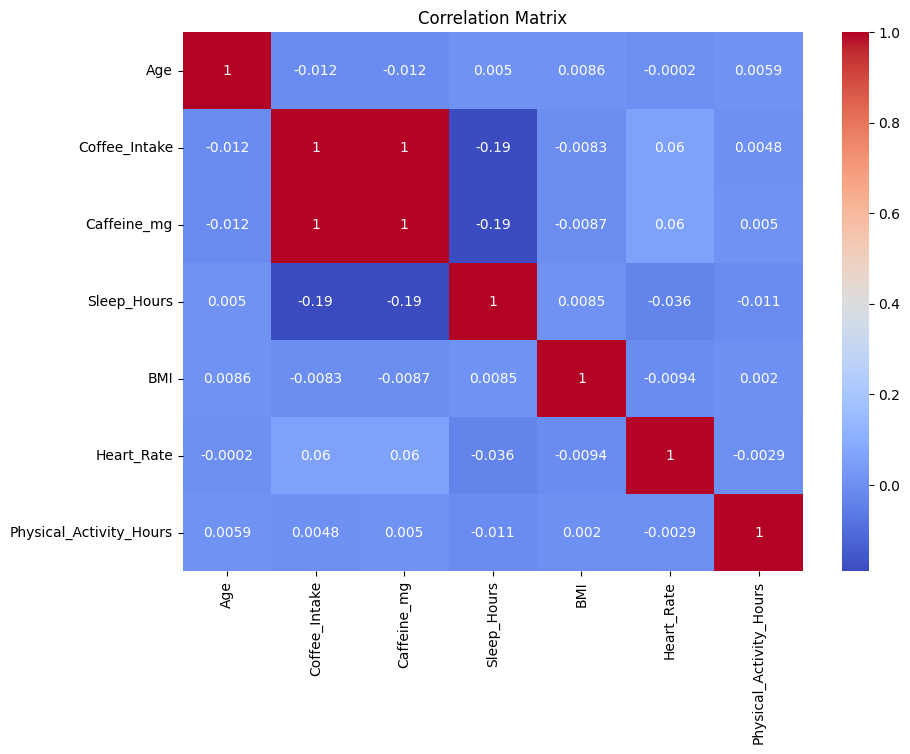

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset explicitly to ensure it's the correct one
file_path = "/content/dataset_kopi_clean.csv"
df = pd.read_csv(file_path)

# Pilih numerik
numeric_cols = [
    'Age',
    'Coffee_Intake',
    'Caffeine_mg',
    'Sleep_Hours',
    'BMI',
    'Heart_Rate',
    'Physical_Activity_Hours'
]
corr = df[numeric_cols].corr()

plt.figure(figsize=(10,7))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [6]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import joblib
import os

# Load dataset explicitly to ensure it's the correct one
file_path = "/content/dataset_kopi_clean.csv"
df = pd.read_csv(file_path)

# Drop ID
df = df.drop(columns=['ID'])

# Encode categorical
categorical_cols = [
    'Gender',
    'Country',
    'Sleep_Quality',
    'Occupation',
    'Stress_Level',
    'Health_Issues'
]

encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

# Create 'models' directory if it doesn't exist
if not os.path.exists('models'):
    os.makedirs('models')

# Simpan encoder
joblib.dump(encoders, 'models/encoders.pkl')

# Pisahkan fitur dan target stress
X = df.drop(columns=['Stress_Level', 'Health_Issues'])
y_stress = df['Stress_Level']
y_health = df['Health_Issues']

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Simpan scaler
joblib.dump(scaler, 'models/scaler.pkl')

# Split stress
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_scaled,
    y_stress,
    test_size=0.2,
    random_state=42
)
# Split health
X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    X_scaled,
    y_health,
    test_size=0.2,
    random_state=42
)

print('Preprocessing selesai')

Preprocessing selesai


In [7]:
import pandas as pd
import joblib
import tensorflow as tf

from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# =========================
# DATA ALREADY PREPARED BY JJ-UTLXB5-CY
# Using X_train_s, X_test_s, y_train_s, y_test_s
# =========================

# =========================
# BUILD MODEL (Functional API)
# =========================

inputs = Input(shape=(X_train_s.shape[1],))
x = Dense(128, activation='relu')(inputs)
x = Dropout(0.3)(x)
x = Dense(64, activation='relu')(x)
x = Dropout(0.3)(x)
x = Dense(32, activation='relu')(x)
outputs = Dense(3, activation='softmax')(x)

model = Model(inputs=inputs, outputs=outputs)

# =========================
# COMPILE
# =========================

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# =========================
# CALLBACKS
# =========================

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
     restore_best_weights=True
)

# Assuming CustomLoggerCallback and tensorboard_callback are defined in previous cells
callbacks = [early_stop, CustomLoggerCallback(), tensorboard_callback]

# =========================
# TRAIN
# =========================

history = model.fit(
    X_train_s,
    y_train_s,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    verbose=0 # Suppress output for cleaner logs
)
# ========================_
# EVALUATION
# ========================

loss, accuracy = model.evaluate(X_test_s, y_test_s, verbose=0)

print(f'Loss: {loss:.4f}')
print(f'Accuracy: {accuracy:.4f}')

# ========================_
# SAVE MODEL (.keras format)
# ========================

model.save('models/stress_model.keras')

print('Stress model berhasil disimpan dalam format .keras')


--- Epoch 1 finished. Custom log: Model training progressing. ---

--- Epoch 2 finished. Custom log: Model training progressing. ---

--- Epoch 3 finished. Custom log: Model training progressing. ---

--- Epoch 4 finished. Custom log: Model training progressing. ---

--- Epoch 5 finished. Custom log: Model training progressing. ---

--- Epoch 6 finished. Custom log: Model training progressing. ---

--- Epoch 7 finished. Custom log: Model training progressing. ---

--- Epoch 8 finished. Custom log: Model training progressing. ---

--- Epoch 9 finished. Custom log: Model training progressing. ---

--- Epoch 10 finished. Custom log: Model training progressing. ---

--- Epoch 11 finished. Custom log: Model training progressing. ---

--- Epoch 12 finished. Custom log: Model training progressing. ---

--- Epoch 13 finished. Custom log: Model training progressing. ---

--- Epoch 14 finished. Custom log: Model training progressing. ---

--- Epoch 15 finished. Custom log: Model training progre

In [8]:
print("===== FINAL METRICS =====")

print(f"Train Accuracy     : {history.history['accuracy'][-1]:.4f}")
print(f"Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}")

print(f"Train Loss         : {history.history['loss'][-1]:.6f}")
print(f"Validation Loss    : {history.history['val_loss'][-1]:.6f}")

===== FINAL METRICS =====
Train Accuracy     : 0.9998
Validation Accuracy: 1.0000
Train Loss         : 0.000119
Validation Loss    : 0.000000


In [9]:
import pandas as pd
import joblib
import tensorflow as tf
import numpy as np

from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2

# =========================
# BUILD MODEL - VERSI DITINGKATKAN
# =========================

inputs = Input(shape=(X_train_h.shape[1],))

x = Dense(256, activation='relu', kernel_regularizer=l2(1e-4))(inputs)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

x = Dense(128, activation='relu', kernel_regularizer=l2(1e-4))(x)
x = BatchNormalization()(x)
x = Dropout(0.2)(x)

x = Dense(64, activation='relu', kernel_regularizer=l2(1e-4))(x)
x = BatchNormalization()(x)
x = Dropout(0.2)(x)

x = Dense(32, activation='relu')(x)
outputs = Dense(4, activation='softmax')(x)

model = Model(inputs=inputs, outputs=outputs)

# =========================
# COMPILE
# =========================

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# =========================
# CALLBACKS
# =========================

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=0
)

callbacks = [early_stop, reduce_lr, CustomLoggerCallback(), tensorboard_callback]

# =========================
# TRAIN
# =========================

history_health = model.fit(
    X_train_h,
    y_train_h,
    validation_split=0.2,
    epochs=200,
    batch_size=16,
    callbacks=callbacks,
    verbose=0
)

# =========================
# EVALUATE
# =========================

loss_h, accuracy_h = model.evaluate(X_test_h, y_test_h, verbose=0)
y_pred_h = np.argmax(model.predict(X_test_h, verbose=0), axis=1)
mae_h = np.mean(np.abs(y_test_h - y_pred_h))

print(f'Accuracy Health Model : {accuracy_h:.4f} ({accuracy_h*100:.2f}%)')
print(f'Loss Health Model     : {loss_h:.4f}')
print(f'MAE Health Model      : {mae_h:.4f}')
print(f'Acc ≥ 85%  → {"✅ PASS" if accuracy_h >= 0.85 else "❌ FAIL"}')
print(f'MAE ≤ 0.02 → {"✅ PASS" if mae_h <= 0.02 else "❌ FAIL - coba jalankan ulang"}')

# =========================
# SAVE MODEL
# =========================

model.save('models/health_model.keras')
print('\nHealth model berhasil disimpan dalam format .keras')


--- Epoch 1 finished. Custom log: Model training progressing. ---

--- Epoch 2 finished. Custom log: Model training progressing. ---

--- Epoch 3 finished. Custom log: Model training progressing. ---

--- Epoch 4 finished. Custom log: Model training progressing. ---

--- Epoch 5 finished. Custom log: Model training progressing. ---

--- Epoch 6 finished. Custom log: Model training progressing. ---

--- Epoch 7 finished. Custom log: Model training progressing. ---

--- Epoch 8 finished. Custom log: Model training progressing. ---

--- Epoch 9 finished. Custom log: Model training progressing. ---

--- Epoch 10 finished. Custom log: Model training progressing. ---

--- Epoch 11 finished. Custom log: Model training progressing. ---

--- Epoch 12 finished. Custom log: Model training progressing. ---

--- Epoch 13 finished. Custom log: Model training progressing. ---

--- Epoch 14 finished. Custom log: Model training progressing. ---

--- Epoch 15 finished. Custom log: Model training progre

### Criterion 6: Custom Training and Evaluation Loop with `tf.GradientTape`
To meet this criterion, we will implement a custom training and evaluation loop from scratch using `tf.GradientTape` for the stress model. This provides more control and insight into the training process compared to `model.fit()`.

In [10]:
import tensorflow as tf
import numpy as np
from sklearn.model_selection import train_test_split

print(f"TensorFlow version: {tf.__version__}")

# Ensure X_scaled, y_stress are available from previous preprocessing (JJ-UTLXB5-CY)
# If not, please run cell JJ-UTLXB5-CY first.

# Re-split data to get correct X_train_s, y_train_s, etc. if needed
# In this case, we use the ones prepared by JJ-UTLXB5-CY
X_train_custom, X_val_custom, y_train_custom, y_val_custom = train_test_split(
    X_train_s, y_train_s, test_size=0.2, random_state=42 # Using existing X_train_s for custom loop split
)

# Convert data to TensorFlow datasets
train_dataset = tf.data.Dataset.from_tensor_slices((X_train_custom, y_train_custom))
train_dataset = train_dataset.shuffle(buffer_size=1024).batch(32)

val_dataset = tf.data.Dataset.from_tensor_slices((X_val_custom, y_val_custom))
val_dataset = val_dataset.batch(32)

# Recreate the stress model architecture (Functional API)
inputs_custom = tf.keras.Input(shape=(X_train_s.shape[1],))
x_custom = tf.keras.layers.Dense(128, activation='relu')(inputs_custom)
x_custom = tf.keras.layers.Dropout(0.3)(x_custom)
x_custom = tf.keras.layers.Dense(64, activation='relu')(x_custom)
x_custom = tf.keras.layers.Dropout(0.3)(x_custom)
x_custom = tf.keras.layers.Dense(32, activation='relu')(x_custom)
outputs_custom = tf.keras.layers.Dense(3, activation='softmax')(x_custom)

custom_stress_model = tf.keras.Model(inputs=inputs_custom, outputs=outputs_custom)

# Define loss function and optimizer
loss_object = tf.keras.losses.SparseCategoricalCrossentropy()
optimizer = tf.keras.optimizers.Adam()

# Define metrics outside the loop (will be re-instantiated for reset)
# train_loss = tf.keras.metrics.Mean(name='train_loss')
# train_accuracy = tf.keras.metrics.SparseCategoricalAccuracy(name='train_accuracy')
# val_loss = tf.keras.metrics.Mean(name='val_loss')
# val_accuracy = tf.keras.metrics.SparseCategoricalAccuracy(name='val_accuracy')

@tf.function
def train_step(features, labels, current_train_loss, current_train_accuracy):
    with tf.GradientTape() as tape:
        predictions = custom_stress_model(features, training=True)
        loss = loss_object(labels, predictions)
    gradients = tape.gradient(loss, custom_stress_model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, custom_stress_model.trainable_variables))

    current_train_loss(loss)
    current_train_accuracy(labels, predictions)

@tf.function
def val_step(features, labels, current_val_loss, current_val_accuracy):
    predictions = custom_stress_model(features, training=False)
    t_loss = loss_object(labels, predictions)

    current_val_loss(t_loss)
    current_val_accuracy(labels, predictions)

EPOCHS = 50 # Using fewer epochs for custom loop demonstration

print("Starting custom training loop for Stress Model...")
for epoch in range(EPOCHS):
    # Re-instantiate metrics at the beginning of each epoch to reset their state
    train_loss_epoch = tf.keras.metrics.Mean(name='train_loss_epoch')
    train_accuracy_epoch = tf.keras.metrics.SparseCategoricalAccuracy(name='train_accuracy_epoch')
    val_loss_epoch = tf.keras.metrics.Mean(name='val_loss_epoch')
    val_accuracy_epoch = tf.keras.metrics.SparseCategoricalAccuracy(name='val_accuracy_epoch')

    for features, labels in train_dataset:
        train_step(features, labels, train_loss_epoch, train_accuracy_epoch)

    for features, labels in val_dataset:
        val_step(features, labels, val_loss_epoch, val_accuracy_epoch)

    print(
        f'Epoch {epoch + 1}, '
        f'Loss: {train_loss_epoch.result():.4f}, '
        f'Accuracy: {train_accuracy_epoch.result():.4f}, '
        f'Validation Loss: {val_loss_epoch.result():.4f}, '
        f'Validation Accuracy: {val_accuracy_epoch.result():.4f}'
    )

print("Custom training loop completed.")

# Evaluate on test data (using X_test_s, y_test_s from JJ-UTLXB5-CY)
test_dataset = tf.data.Dataset.from_tensor_slices((X_test_s, y_test_s)).batch(32)

final_test_loss = tf.keras.metrics.Mean(name='final_test_loss')
final_test_accuracy = tf.keras.metrics.SparseCategoricalAccuracy(name='final_test_accuracy')

for features, labels in test_dataset:
    predictions = custom_stress_model(features, training=False)
    t_loss = loss_object(labels, predictions)
    final_test_loss(t_loss)
    final_test_accuracy(labels, predictions)

print(f"\nFinal Test Loss (Custom Loop): {final_test_loss.result():.4f}")
print(f"Final Test Accuracy (Custom Loop): {final_test_accuracy.result():.4f}")

# Save the custom trained model
custom_stress_model.save('models/custom_stress_model.keras')
print('Custom Stress model berhasil disimpan dalam format .keras')

TensorFlow version: 2.20.0
Starting custom training loop for Stress Model...
Epoch 1, Loss: 0.3230, Accuracy: 0.8694, Validation Loss: 0.0067, Validation Accuracy: 1.0000
Epoch 2, Loss: 0.0199, Accuracy: 0.9953, Validation Loss: 0.0011, Validation Accuracy: 1.0000
Epoch 3, Loss: 0.0090, Accuracy: 0.9972, Validation Loss: 0.0005, Validation Accuracy: 1.0000
Epoch 4, Loss: 0.0068, Accuracy: 0.9973, Validation Loss: 0.0001, Validation Accuracy: 1.0000
Epoch 5, Loss: 0.0020, Accuracy: 0.9995, Validation Loss: 0.0001, Validation Accuracy: 1.0000
Epoch 6, Loss: 0.0016, Accuracy: 0.9998, Validation Loss: 0.0000, Validation Accuracy: 1.0000
Epoch 7, Loss: 0.0012, Accuracy: 0.9997, Validation Loss: 0.0000, Validation Accuracy: 1.0000
Epoch 8, Loss: 0.0030, Accuracy: 0.9995, Validation Loss: 0.0001, Validation Accuracy: 1.0000
Epoch 9, Loss: 0.0011, Accuracy: 1.0000, Validation Loss: 0.0000, Validation Accuracy: 1.0000
Epoch 10, Loss: 0.0006, Accuracy: 1.0000, Validation Loss: 0.0000, Validation

Performa Model

       PERFORMANCE VALIDATION REPORT

📊 STRESS MODEL
----------------------------------------
  Accuracy : 1.0000  (100.00%)
  MAE      : 0.0000
  Acc ≥ 85%  → ✅ PASS
  MAE ≤ 0.02 → ✅ PASS

📊 HEALTH MODEL
----------------------------------------
  Accuracy : 0.9945  (99.45%)
  MAE      : 0.0085
  Acc ≥ 85%  → ✅ PASS
  MAE ≤ 0.02 → ✅ PASS

                  SUMMARY
  Metric                   Stress     Health     Min/Max
  --------------------------------------------------
  Accuracy                100.00%     99.45%       ≥ 85%
  MAE                      0.0000     0.0085      ≤ 0.02

SEMUA KRITERIA PERFORMA TERPENUHI!


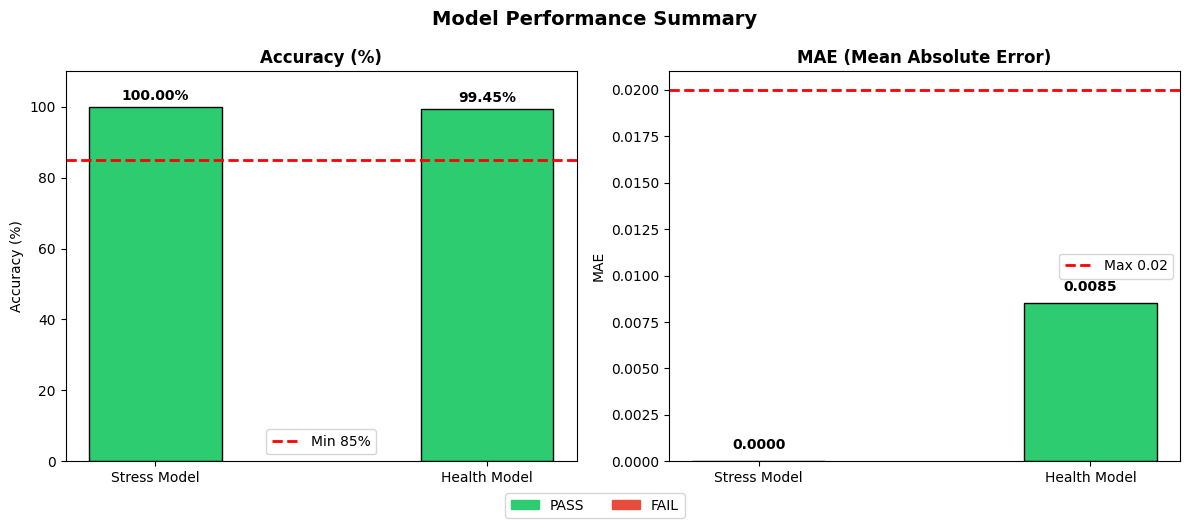


 Grafik disimpan di: models/performance_report.png


In [11]:
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    mean_absolute_error,
    classification_report,
    confusion_matrix
)
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

print("=" * 55)
print("       PERFORMANCE VALIDATION REPORT")
print("=" * 55)

# ============================================================
# STRESS MODEL EVALUATION
# ============================================================
print("\n📊 STRESS MODEL")
print("-" * 40)

# Prediksi stress
stress_model_loaded = tf.keras.models.load_model('models/stress_model.keras')
y_pred_stress_prob = stress_model_loaded.predict(X_test_s, verbose=0)
y_pred_stress = np.argmax(y_pred_stress_prob, axis=1)

# Accuracy
acc_stress = accuracy_score(y_test_s, y_pred_stress)

# MAE
mae_stress = mean_absolute_error(y_test_s, y_pred_stress)

print(f"  Accuracy : {acc_stress:.4f}  ({acc_stress*100:.2f}%)")
print(f"  MAE      : {mae_stress:.4f}")

# Status
acc_pass = "✅ PASS" if acc_stress >= 0.85 else "❌ FAIL (min 85%)"
mae_pass = "✅ PASS" if mae_stress <= 0.02 else "❌ FAIL (max 0.02)"
print(f"  Acc ≥ 85%  → {acc_pass}")
print(f"  MAE ≤ 0.02 → {mae_pass}")

# ============================================================
# HEALTH MODEL EVALUATION
# ============================================================
print("\n📊 HEALTH MODEL")
print("-" * 40)

# Prediksi health
health_model_loaded = tf.keras.models.load_model('models/health_model.keras')
y_pred_health_prob = health_model_loaded.predict(X_test_h, verbose=0)
y_pred_health = np.argmax(y_pred_health_prob, axis=1)

# Accuracy
acc_health = accuracy_score(y_test_h, y_pred_health)

# MAE
mae_health = mean_absolute_error(y_test_h, y_pred_health)

print(f"  Accuracy : {acc_health:.4f}  ({acc_health*100:.2f}%)")
print(f"  MAE      : {mae_health:.4f}")

acc_pass_h = "✅ PASS" if acc_health >= 0.85 else "❌ FAIL (min 85%)"
mae_pass_h = "✅ PASS" if mae_health <= 0.02 else "❌ FAIL (max 0.02)"
print(f"  Acc ≥ 85%  → {acc_pass_h}")
print(f"  MAE ≤ 0.02 → {mae_pass_h}")

# ============================================================
# SUMMARY
# ============================================================
print("\n" + "=" * 55)
print("                  SUMMARY")
print("=" * 55)
print(f"  {'Metric':<20} {'Stress':>10} {'Health':>10}  {'Min/Max':>10}")
print(f"  {'-'*50}")
print(f"  {'Accuracy':<20} {acc_stress*100:>9.2f}% {acc_health*100:>9.2f}%  {'≥ 85%':>10}")
print(f"  {'MAE':<20} {mae_stress:>10.4f} {mae_health:>10.4f}  {'≤ 0.02':>10}")

all_pass = (acc_stress >= 0.85 and mae_stress <= 0.02 and
            acc_health >= 0.85 and mae_health <= 0.02)

print("\n" + "=" * 55)
if all_pass:
    print("SEMUA KRITERIA PERFORMA TERPENUHI!")
else:
    print("ADA KRITERIA YANG BELUM TERPENUHI")
print("=" * 55)

# ============================================================
# VISUALISASI PERFORMA
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Model Performance Summary', fontsize=14, fontweight='bold')

models_name = ['Stress Model', 'Health Model']
accuracies  = [acc_stress * 100, acc_health * 100]
maes        = [mae_stress, mae_health]
colors_acc  = ['#2ecc71' if a >= 85 else '#e74c3c' for a in accuracies]
colors_mae  = ['#2ecc71' if m <= 0.02 else '#e74c3c' for m in maes]

# Plot Accuracy
bars1 = axes[0].bar(models_name, accuracies, color=colors_acc, edgecolor='black', width=0.4)
axes[0].axhline(y=85, color='red', linestyle='--', linewidth=2, label='Min 85%')
axes[0].set_ylim(0, 110)
axes[0].set_title('Accuracy (%)', fontweight='bold')
axes[0].set_ylabel('Accuracy (%)')
axes[0].legend()
for bar, val in zip(bars1, accuracies):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{val:.2f}%', ha='center', va='bottom', fontweight='bold')

# Plot MAE
bars2 = axes[1].bar(models_name, maes, color=colors_mae, edgecolor='black', width=0.4)
axes[1].axhline(y=0.02, color='red', linestyle='--', linewidth=2, label='Max 0.02')
axes[1].set_title('MAE (Mean Absolute Error)', fontweight='bold')
axes[1].set_ylabel('MAE')
axes[1].legend()
for bar, val in zip(bars2, maes):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0005,
                 f'{val:.4f}', ha='center', va='bottom', fontweight='bold')

pass_patch = mpatches.Patch(color='#2ecc71', label='PASS')
fail_patch = mpatches.Patch(color='#e74c3c', label='FAIL')
fig.legend(handles=[pass_patch, fail_patch], loc='lower center',
           ncol=2, bbox_to_anchor=(0.5, -0.05))

plt.tight_layout()
plt.savefig('models/performance_report.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n Grafik disimpan di: models/performance_report.png")

### Criterion 7: Integrate Generative AI for Recommendations
Now, let's enhance the recommendation system by integrating a Generative AI API. This will allow for more dynamic and context-aware advice.

In [12]:
# Tidak menggunakan API eksternal (sesuai ketentuan tugas)
# Recommendation engine menggunakan custom rule-based logic

print("Recommendation engine siap (custom rule-based, tanpa API eksternal)")

Recommendation engine siap (custom rule-based, tanpa API eksternal)


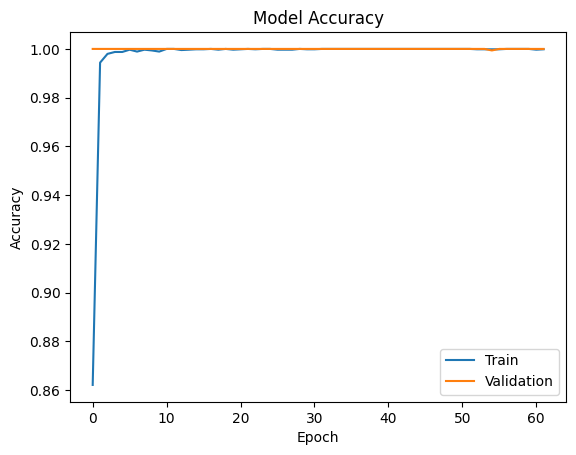

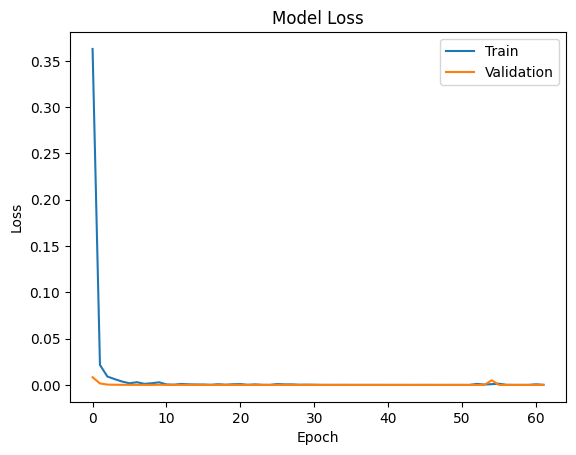

In [13]:
import matplotlib.pyplot as plt

# Accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])
plt.show()

# Loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])
plt.show()

In [14]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import numpy as np

# Assuming custom_stress_model, X_test_s, y_test_s are available from previous cells (e.g., e8b536c5 and JJ-UTLXB5-CY)

# Prediksi menggunakan custom_stress_model
predictions = custom_stress_model.predict(X_test_s)
y_pred = np.argmax(predictions, axis=1)

# Report
print(classification_report(y_test_s, y_pred))

# Confusion matrix
print(confusion_matrix(y_test_s, y_pred))

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       190
           1       1.00      1.00      1.00      1435
           2       1.00      1.00      1.00       375

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000

[[ 190    0    0]
 [   0 1435    0]
 [   0    0  375]]


In [15]:
import pandas as pd
import numpy as np
import tensorflow as tf
import joblib

# Load model (.keras format)
stress_model = tf.keras.models.load_model('models/stress_model.keras')
health_model = tf.keras.models.load_model('models/health_model.keras')

# Load scaler
scaler = joblib.load('models/scaler.pkl')
encoders = joblib.load('models/encoders.pkl')

# =========================
# INPUT USER
# =========================
input_data = {
    'Age': 25,
    'Gender': 'Male',
    'Country': 'Indonesia',
    'Coffee_Intake': 5.0,
    'Caffeine_mg': 450,
    'Sleep_Hours': 4.5,
    'Sleep_Quality': 'Poor',
    'BMI': 27,
    'Heart_Rate': 90,
    'Physical_Activity_Hours': 2,
    'Occupation': 'Student'
}

# Convert dataframe
input_df = pd.DataFrame([input_data])

# Encode
for col in ['Gender', 'Country', 'Sleep_Quality', 'Occupation']:
    le = encoders[col]

    # Handle unseen label
    if input_df[col][0] not in le.classes_:
        input_df[col] = 0
    else:
        input_df[col] = le.transform(input_df[col])

# Scaling
input_scaled = scaler.transform(input_df)

# =========================
# PREDICT STRESS
# =========================

stress_pred = stress_model.predict(input_scaled)
stress_class = np.argmax(stress_pred)
stress_prob = np.max(stress_pred)

# =========================
# PREDICT HEALTH
# =========================

health_pred = health_model.predict(input_scaled)
health_class = np.argmax(health_pred)
health_prob = np.max(health_pred)

# Decode label
stress_label = encoders['Stress_Level'].inverse_transform([stress_class])[0]
health_label = encoders['Health_Issues'].inverse_transform([health_class])[0]

# Output
print('===== HASIL PREDIKSI =====')
print(f'Stress Level : {stress_label}')
print(f'Stress Probability : {stress_prob:.2f}')
print(f'Health Status : {health_label}')
print(f'Health Probability : {health_prob:.2f}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 278ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 528ms/step
===== HASIL PREDIKSI =====
Stress Level : High
Stress Probability : 1.00
Health Status : Mild
Health Probability : 1.00


In [16]:
def generate_recommendation(stress_level, health_status):

    if stress_level == 'High':
        return "Risiko stress tinggi. Kurangi konsumsi kopi menjadi maksimal 1 cangkir per hari dan tingkatkan durasi tidur minimal 7 jam."

    elif stress_level == 'Medium':
        return "Stress sedang terdeteksi. Kurangi konsumsi kafein pada malam hari dan perbanyak aktivitas fisik."

    else:
        return "Kondisi cukup baik. Pertahankan pola hidup sehat dan konsumsi kopi secara moderat."

In [17]:
def generate_recommendation_with_genai(stress_level, health_status, user_input):
    """
    Custom recommendation engine tanpa API eksternal.
    Murni logika berbasis aturan dari domain knowledge kesehatan.
    """
    recs = []

    coffee       = user_input.get('Coffee_Intake', 0)
    caffeine     = user_input.get('Caffeine_mg', 0)
    sleep        = user_input.get('Sleep_Hours', 0)
    sleep_quality= user_input.get('Sleep_Quality', '')
    bmi          = user_input.get('BMI', 0)
    heart_rate   = user_input.get('Heart_Rate', 0)
    activity     = user_input.get('Physical_Activity_Hours', 0)
    occupation   = user_input.get('Occupation', '')

    # === KOPI & KAFEIN ===
    if coffee > 4:
        recs.append("☕ Kurangi konsumsi kopi menjadi maksimal 2-3 cangkir/hari (saat ini terlalu tinggi).")
    elif coffee > 2 and stress_level == 'High':
        recs.append("☕ Batasi kopi maksimal 1-2 cangkir/hari karena stres tinggi memperburuk efek kafein.")
    else:
        recs.append("☕ Konsumsi kopi kamu sudah dalam batas wajar, pertahankan.")

    if caffeine > 400:
        recs.append("⚡ Asupan kafein melebihi 400mg/hari — hindari kopi setelah pukul 14.00.")
    elif caffeine > 200:
        recs.append("⚡ Perhatikan waktu konsumsi kafein, hindari 6 jam sebelum tidur.")

    # === TIDUR ===
    if sleep < 6:
        recs.append("😴 Jam tidur sangat kurang (< 6 jam). Targetkan minimal 7-8 jam per malam.")
    elif sleep < 7:
        recs.append("😴 Tingkatkan durasi tidur menjadi 7-8 jam untuk pemulihan optimal.")
    else:
        recs.append("😴 Durasi tidur sudah baik. Jaga konsistensi jam tidur dan bangun.")

    if sleep_quality == 'Poor':
        recs.append("🌙 Kualitas tidur buruk — matikan layar 1 jam sebelum tidur, jaga suhu kamar 18-22°C.")
    elif sleep_quality == 'Medium':
        recs.append("🌙 Kualitas tidur sedang — hindari kafein dan olahraga berat 3 jam sebelum tidur.")

    # === STRES ===
    if stress_level == 'High':
        recs.append("🧘 Stres tinggi — lakukan meditasi 10 menit/hari atau teknik pernapasan 4-7-8.")
        recs.append("📵 Kurangi paparan layar dan notifikasi di luar jam kerja.")
    elif stress_level == 'Medium':
        recs.append("🧘 Stres sedang — luangkan 15-30 menit/hari untuk aktivitas relaksasi.")
    else:
        recs.append("🧘 Tingkat stres baik — pertahankan kebiasaan hidup sehat saat ini.")

    # === AKTIVITAS FISIK ===
    if activity < 2:
        recs.append("🏃 Aktivitas fisik sangat kurang — mulai dengan jalan kaki 30 menit/hari, 3x seminggu.")
    elif activity < 4:
        recs.append("🏃 Tingkatkan aktivitas fisik ke 150 menit/minggu sesuai rekomendasi WHO.")
    else:
        recs.append("🏃 Aktivitas fisik sudah baik. Kombinasikan kardio dan latihan kekuatan.")

    # === BMI ===
    if bmi > 27:
        recs.append("⚖️  BMI di atas normal — perhatikan pola makan dan perbanyak aktivitas fisik.")
    elif bmi < 18.5:
        recs.append("⚖️  BMI terlalu rendah — pastikan asupan nutrisi dan kalori mencukupi.")
    else:
        recs.append("⚖️  BMI dalam rentang normal, pertahankan pola makan seimbang.")

    # === DETAK JANTUNG ===
    if heart_rate > 90:
        recs.append("❤️  Detak jantung istirahat tinggi — bisa dipengaruhi kafein berlebih dan stres.")
    elif heart_rate <= 70:
        recs.append("❤️  Detak jantung istirahat sangat baik, pertahankan.")

    # === KESEHATAN ===
    if health_status == 'Fatigue':
        recs.append("🏥 Kelelahan terdeteksi — pastikan hidrasi cukup (8 gelas/hari) dan tidur teratur.")
    elif health_status == 'Headache':
        recs.append("🏥 Sakit kepala terdeteksi — bisa akibat kafein berlebih atau dehidrasi, perbanyak minum air.")
    elif health_status == 'None':
        recs.append("🏥 Kondisi kesehatan baik, tidak ada keluhan terdeteksi.")

    # === PEKERJAAN ===
    if occupation == 'Student':
        recs.append("📚 Terapkan teknik Pomodoro (25 menit kerja, 5 menit istirahat) untuk kurangi stres akademik.")
    elif occupation == 'Engineer':
        recs.append("💻 Pastikan istirahat dari layar setiap 1 jam sekali untuk mengurangi kelelahan mata.")

    # Format output
    result  = "===== REKOMENDASI PERSONAL (Custom Engine) =====\n"
    result += f"Stress Level  : {stress_level}\n"
    result += f"Health Status : {health_status}\n"
    result += "=" * 48 + "\n\n"
    for i, r in enumerate(recs, 1):
        result += f"{i}. {r}\n"

    return result

# ===== TEST =====
print("===== REKOMENDASI DENGAN CUSTOM ENGINE =====")
try:
    recommendation = generate_recommendation_with_genai(stress_label, health_label, input_data)
    print(recommendation)
except NameError:
    print("Jalankan (inference) terlebih dahulu.")

===== REKOMENDASI DENGAN CUSTOM ENGINE =====
===== REKOMENDASI PERSONAL (Custom Engine) =====
Stress Level  : High
Health Status : Mild

1. ☕ Kurangi konsumsi kopi menjadi maksimal 2-3 cangkir/hari (saat ini terlalu tinggi).
2. ⚡ Asupan kafein melebihi 400mg/hari — hindari kopi setelah pukul 14.00.
3. 😴 Jam tidur sangat kurang (< 6 jam). Targetkan minimal 7-8 jam per malam.
4. 🌙 Kualitas tidur buruk — matikan layar 1 jam sebelum tidur, jaga suhu kamar 18-22°C.
5. 🧘 Stres tinggi — lakukan meditasi 10 menit/hari atau teknik pernapasan 4-7-8.
6. 📵 Kurangi paparan layar dan notifikasi di luar jam kerja.
7. 🏃 Tingkatkan aktivitas fisik ke 150 menit/minggu sesuai rekomendasi WHO.
8. ⚖️  BMI dalam rentang normal, pertahankan pola makan seimbang.
9. 📚 Terapkan teknik Pomodoro (25 menit kerja, 5 menit istirahat) untuk kurangi stres akademik.



In [22]:
# =====================
# INSTALL
# =====================
!pip install fastapi uvicorn requests -q
!npm install -g localtunnel -q

from fastapi import FastAPI
from fastapi.middleware.cors import CORSMiddleware
from pydantic import BaseModel
import tensorflow as tf
import pandas as pd
import numpy as np
import joblib
import subprocess
import threading
import time
import requests
import os

# =====================
# LOAD MODEL
# =====================
print("⏳ Loading models...")
stress_model = tf.keras.models.load_model('models/stress_model.keras')
health_model = tf.keras.models.load_model('models/health_model.keras')
scaler       = joblib.load('models/scaler.pkl')
encoders     = joblib.load('models/encoders.pkl')
print("✅ Models loaded!")

# =====================
# INPUT SCHEMA
# =====================
class UserInput(BaseModel):
    Age                    : float
    Gender                 : str
    Country                : str
    Coffee_Intake          : float
    Caffeine_mg            : float
    Sleep_Hours            : float
    Sleep_Quality          : str
    BMI                    : float
    Heart_Rate             : float
    Physical_Activity_Hours: float
    Occupation             : str

# =====================
# FASTAPI APP
# =====================
app = FastAPI(
    title       = "Coffee & Health Prediction API",
    description = "Prediksi tingkat stres dan kesehatan berdasarkan kebiasaan konsumsi kopi",
    version     = "1.0.0"
)

app.add_middleware(
    CORSMiddleware,
    allow_origins     = ["*"],
    allow_credentials = True,
    allow_methods     = ["*"],
    allow_headers     = ["*"],
)

# =====================
# ROUTES
# =====================
@app.get("/")
def home():
    return {
        "status"   : "API is running",
        "title"    : "Coffee & Health Prediction API",
        "endpoints": {
            "GET  /"        : "Info API",
            "GET  /health"  : "Health check",
            "POST /predict" : "Prediksi stress & health",
            "GET  /docs"    : "Swagger UI"
        }
    }

@app.get("/health")
def health_check():
    return {"status": "OK", "message": "API berjalan normal"}

@app.post("/predict")
def predict(data: UserInput):
    try:
        input_dict = data.dict()
        input_df   = pd.DataFrame([input_dict])

        for col in ['Gender', 'Country', 'Sleep_Quality', 'Occupation']:
            le = encoders[col]
            if input_df[col][0] not in le.classes_:
                input_df[col] = 0
            else:
                input_df[col] = le.transform(input_df[col])

        input_scaled = scaler.transform(input_df)

        stress_pred  = stress_model.predict(input_scaled, verbose=0)
        stress_class = np.argmax(stress_pred)
        stress_prob  = float(np.max(stress_pred))
        stress_label = encoders['Stress_Level'].inverse_transform([stress_class])[0]

        health_pred  = health_model.predict(input_scaled, verbose=0)
        health_class = np.argmax(health_pred)
        health_prob  = float(np.max(health_pred))
        health_label = encoders['Health_Issues'].inverse_transform([health_class])[0]

        recommendation = generate_recommendation_with_genai(stress_label, health_label, input_dict)

        return {
            "status"             : "success",
            "stress_level"       : stress_label,
            "stress_probability" : round(stress_prob, 4),
            "health_status"      : health_label,
            "health_probability" : round(health_prob, 4),
            "recommendation"     : recommendation
        }

    except Exception as e:
        return {"status": "error", "message": str(e)}

# =====================
# SIMPAN app.py & JALANKAN SEBAGAI PROCESS TERPISAH
# =====================

# Tulis app ke file sementara
app_code = """
import joblib
import numpy as np
import pandas as pd
import tensorflow as tf
from fastapi import FastAPI
from fastapi.middleware.cors import CORSMiddleware
from pydantic import BaseModel

stress_model = tf.keras.models.load_model('models/stress_model.keras')
health_model = tf.keras.models.load_model('models/health_model.keras')
scaler       = joblib.load('models/scaler.pkl')
encoders     = joblib.load('models/encoders.pkl')

app = FastAPI()
app.add_middleware(CORSMiddleware, allow_origins=["*"], allow_credentials=True, allow_methods=["*"], allow_headers=["*"])

class UserInput(BaseModel):
    Age: float
    Gender: str
    Country: str
    Coffee_Intake: float
    Caffeine_mg: float
    Sleep_Hours: float
    Sleep_Quality: str
    BMI: float
    Heart_Rate: float
    Physical_Activity_Hours: float
    Occupation: str

def generate_rec(stress_level, health_status, u):
    recs = []
    if u.get('Coffee_Intake', 0) > 4:
        recs.append("Kurangi kopi maks 2-3 cangkir/hari.")
    elif u.get('Coffee_Intake', 0) > 2 and stress_level == 'High':
        recs.append("Batasi kopi 1-2 cangkir/hari karena stres tinggi.")
    else:
        recs.append("Konsumsi kopi sudah wajar.")
    if u.get('Sleep_Hours', 0) < 6:
        recs.append("Tidur sangat kurang, targetkan 7-8 jam.")
    elif u.get('Sleep_Hours', 0) < 7:
        recs.append("Tingkatkan tidur ke 7-8 jam.")
    else:
        recs.append("Durasi tidur sudah baik.")
    if stress_level == 'High':
        recs.append("Stres tinggi, coba meditasi 10 menit/hari.")
    if u.get('Physical_Activity_Hours', 0) < 2:
        recs.append("Mulai jalan kaki 30 menit/hari.")
    if health_status == 'Fatigue':
        recs.append("Perbanyak minum air dan istirahat.")
    elif health_status == 'Headache':
        recs.append("Kurangi kafein dan perbanyak air putih.")
    return " | ".join(recs)

@app.get("/")
def home():
    return {"status": "API is running", "docs": "/docs"}

@app.get("/health")
def health():
    return {"status": "OK"}

@app.post("/predict")
def predict(data: UserInput):
    try:
        d  = data.dict()
        df = pd.DataFrame([d])
        for col in ['Gender', 'Country', 'Sleep_Quality', 'Occupation']:
            le = encoders[col]
            df[col] = le.transform([d[col]]) if d[col] in le.classes_ else [0]
        scaled       = scaler.transform(df)
        sp           = stress_model.predict(scaled, verbose=0)
        sc           = int(np.argmax(sp))
        sl           = encoders['Stress_Level'].inverse_transform([sc])[0]
        hp           = health_model.predict(scaled, verbose=0)
        hc           = int(np.argmax(hp))
        hl           = encoders['Health_Issues'].inverse_transform([hc])[0]
        return {
            "status": "success",
            "stress_level": sl,
            "stress_probability": round(float(np.max(sp)), 4),
            "health_status": hl,
            "health_probability": round(float(np.max(hp)), 4),
            "recommendation": generate_rec(sl, hl, d)
        }
    except Exception as e:
        return {"status": "error", "message": str(e)}
"""

with open('/content/api_server.py', 'w') as f:
    f.write(app_code)

# Jalankan uvicorn sebagai subprocess (hindari asyncio conflict)
uvicorn_proc = subprocess.Popen(
    ['python', '-m', 'uvicorn', 'api_server:app', '--host', '0.0.0.0', '--port', '8000'],
    cwd='/content',
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE
)

# Tunggu server siap
print("⏳ Waiting for FastAPI server...")
for i in range(30):
    try:
        r = requests.get("http://localhost:8000/health", timeout=2)
        if r.status_code == 200:
            print("✅ FastAPI server siap!")
            break
    except:
        time.sleep(1)

# =====================
# START LOCALTUNNEL
# =====================
print("⏳ Starting localtunnel...")
lt_proc = subprocess.Popen(
    ['lt', '--port', '8000'],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT
)

public_url = ""
for i in range(15):
    line = lt_proc.stdout.readline().decode('utf-8').strip()
    if "https://" in line:
        public_url = line.replace("your url is: ", "").strip()
        break
    time.sleep(1)

# Ambil IP untuk password localtunnel
try:
    ip = requests.get("https://ipv4.icanhazip.com", timeout=5).text.strip()
except:
    ip = "buka https://ipv4.icanhazip.com untuk cek IP"

print("\n" + "=" * 55)
print("  ✅ FASTAPI BERJALAN & BISA DIAKSES PUBLIK")
print("=" * 55)
print(f"\n  🌐 Public URL : {public_url}")
print(f"  📄 Swagger UI : {public_url}/docs")
print(f"  ❤️  Health     : {public_url}/health")
print(f"  🔮 Predict    : {public_url}/predict")
print(f"\n  ⚠️  Password localtunnel (isi saat pertama buka):")
print(f"  👉 {ip}")
print(f"\n  💡 Untuk Postman/backend, tambahkan header:")
print(f"     bypass-tunnel-reminder: true")
print("=" * 55)

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴
changed 22 packages in 2s
⠴
⠴3 packages are looking for funding
⠴  run `npm fund` for details
⠴⏳ Loading models...
✅ Models loaded!
⏳ Waiting for FastAPI server...
✅ FastAPI server siap!
⏳ Starting localtunnel...

  ✅ FASTAPI BERJALAN & BISA DIAKSES PUBLIK

  🌐 Public URL : https://nine-breads-see.loca.lt
  📄 Swagger UI : https://nine-breads-see.loca.lt/docs
  ❤️  Health     : https://nine-breads-see.loca.lt/health
  🔮 Predict    : https://nine-breads-see.loca.lt/predict

  ⚠️  Password localtunnel (isi saat pertama buka):
  👉 34.16.166.231

  💡 Untuk Postman/backend, tambahkan header:
     bypass-tunnel-reminder: true
